In [ ]:
!pip install ultralytics opencv-python streamlit

In [ ]:
from ultralytics import YOLO
print("YOLO imported successfully!")

YOLO imported successfully!


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 13219337_2560_1440_24fps.mp4 to 13219337_2560_1440_24fps (6).mp4


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

In [ ]:
vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}
print(vehicle_classes)

{2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.predict(
    source="13219337_2560_1440_24fps.mp4",
    save=True,
    conf=0.4,
    project="output",
    name="detection",
    exist_ok=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/517) /content/13219337_2560_1440_24fps.mp4: 384x640 2 persons, 7 cars, 1 motorcycle, 1 umbrella, 10.6ms
video 1/1 (frame 2/517) /content/13219337_2560_1440_24fps.mp4: 384x640 2 persons, 7 cars, 1 motorcycle, 1 umbrella, 9.9ms
video 1/1 (frame 3/517) /content/13219337_2560_1440_24fps.mp4: 384x640 3 persons, 7 cars, 1 motorcycle, 1 umbrella, 9.0ms
video 1/1 (frame 4/517) /content/13219337_2560_1440_24fps.mp4: 384x640 5 persons, 7 cars, 1

In [ ]:
import os
output_path = "/content/runs/detect/output/detection"
print(os.listdir(output_path))

['13219337_2560_1440_24fps.avi']


In [ ]:
import cv2
input_video = "/content/runs/detect/output/detection/13219337_2560_1440_24fps.avi"
output_video = "/content/traffic_detected.mp4"
cap = cv2.VideoCapture(input_video)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
print("Width:", width)
print("Height:", height)
print("FPS:", fps)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)
cap.release()
out.release()
print("Conversion completed!")

Width: 2560
Height: 1440
FPS: 24.0
Conversion completed!


In [ ]:
from IPython.display import Video
Video("/content/traffic_detected.mp4", embed=True)

In [ ]:
!ffmpeg -y -i "/content/runs/detect/output/detection/13219337_2560_1440_24fps.avi" \
-c:v libx264 -pix_fmt yuv420p -c:a aac \
"/content/traffic_detected_h264.mp4"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
import os
print(os.path.exists("/content/traffic_detected_h264.mp4"))
print(os.path.getsize("/content/traffic_detected_h264.mp4") / (1024*1024), "MB")

True
48.73597717285156 MB


In [ ]:
from IPython.display import Video
Video("/content/traffic_detected_h264.mp4", embed=True)

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [ ]:
results = model.track(
    source="13219337_2560_1440_24fps.mp4",
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    stream=True,
    save=True,
    project="tracking",
    name="vehicle_tracking",
    exist_ok=True,
    verbose=False
)

print("Tracking started successfully.")

Tracking started successfully.


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.track(
    source="13219337_2560_1440_24fps.mp4",
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    persist=True,
    verbose=False
)
for result in results:
    if result.boxes.id is not None:
        ids = result.boxes.id.cpu().numpy().astype(int)
        print("Tracking IDs:", ids)
        break

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Tracking IDs: [1 2 3 4 5 6 7 8]


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.track(
    source="13219337_2560_1440_24fps.mp4",
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    persist=True,
    verbose=False
)
total_frames = 0
frames_with_vehicles = 0
for result in results:
    total_frames += 1
    if result.boxes.id is not None:
        if len(result.boxes.id) > 0:
            frames_with_vehicles += 1
print("Total frames processed:", total_frames)
print("Frames with tracked vehicles:", frames_with_vehicles)

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Total frames processed: 517
Frames with tracked vehicles: 517


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
video_path = "13219337_2560_1440_24fps.mp4"
results = model.track(
    source=video_path,
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    persist=True,
    stream=True,
    verbose=False
)
class_names = {
    2: "Car",
    3: "Bike",
    5: "Bus",
    7: "Truck"
}
vehicle_tracks = {}
for result in results:
    if result.boxes.id is None:
        continue
    classes = result.boxes.cls.cpu().numpy().astype(int)
    ids = result.boxes.id.cpu().numpy().astype(int)
    for cls, track_id in zip(classes, ids):
        if track_id not in vehicle_tracks:
            vehicle_tracks[track_id] = {
                "class": cls,
                "frames": 0
            }
        vehicle_tracks[track_id]["frames"] += 1
valid_tracks = {
    track_id: data
    for track_id, data in vehicle_tracks.items()
    if data["frames"] >= 5
}
vehicle_counts = {
    "Car": 0,
    "Bike": 0,
    "Bus": 0,
    "Truck": 0
}
for track_id, data in valid_tracks.items():
    vehicle_name = class_names.get(data["class"])
    if vehicle_name:
        vehicle_counts[vehicle_name] += 1
print("Vehicle Counting Results")
print("------------------------")
print("Cars   :", vehicle_counts["Car"])
print("Bikes  :", vehicle_counts["Bike"])
print("Buses  :", vehicle_counts["Bus"])
print("Trucks :", vehicle_counts["Truck"])
print("------------------------")
print("Total  :", sum(vehicle_counts.values()))
print()
print("Unique tracked vehicles:", len(valid_tracks))

Vehicle Counting Results
------------------------
Cars   : 55
Bikes  : 7
Buses  : 2
Trucks : 1
------------------------
Total  : 65

Unique tracked vehicles: 65


In [ ]:
from ultralytics import YOLO
import numpy as np
model = YOLO("yolov8n.pt")
video_path = "13219337_2560_1440_24fps.mp4"
results = model.track(
    source=video_path,
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    stream=True,
    verbose=False
)
vehicles_per_frame = []
for result in results:
    if result.boxes.id is not None:
        count = len(result.boxes.id)
    else:
        count = 0
    vehicles_per_frame.append(count)
print("Frames analyzed:", len(vehicles_per_frame))
print("Average vehicles per frame:", round(np.mean(vehicles_per_frame), 2))
print("Maximum vehicles in one frame:", max(vehicles_per_frame))
print("Minimum vehicles in one frame:", min(vehicles_per_frame))

Frames analyzed: 517
Average vehicles per frame: 6.42
Maximum vehicles in one frame: 11
Minimum vehicles in one frame: 2


In [ ]:
average_vehicles = 6.42
maximum_vehicles = 11
if average_vehicles <= 4:
    congestion = "LOW"
elif average_vehicles <= 7:
    congestion = "MEDIUM"
else:
    congestion = "HIGH"
print("Traffic Density :", round(average_vehicles, 2), "vehicles/frame")
print("Maximum Vehicles :", maximum_vehicles)
print("Congestion Status:", congestion)

Traffic Density : 6.42 vehicles/frame
Maximum Vehicles : 11
Congestion Status: MEDIUM


In [ ]:
import numpy as np
average_density = np.mean(vehicles_per_frame)
maximum_density = max(vehicles_per_frame)
minimum_density = min(vehicles_per_frame)
if average_density <= 4:
    congestion_status = "LOW"
elif average_density <= 7:
    congestion_status = "MEDIUM"
else:
    congestion_status = "HIGH"
print("================================")
print("TRAFFIC ANALYSIS")
print("================================")
print(f"Average vehicles/frame : {average_density:.2f}")
print(f"Maximum vehicles/frame : {maximum_density}")
print(f"Minimum vehicles/frame : {minimum_density}")
print(f"Congestion Status       : {congestion_status}")
print("================================")

TRAFFIC ANALYSIS
Average vehicles/frame : 6.42
Maximum vehicles/frame : 11
Minimum vehicles/frame : 2
Congestion Status       : MEDIUM


In [ ]:
from ultralytics import YOLO
import numpy as np
model = YOLO("yolov8n.pt")
video_path = "13219337_2560_1440_24fps.mp4"
results = model.track(
    source=video_path,
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    stream=True,
    verbose=False
)
frame_area = 2560 * 1440
density_values = []
for result in results:
    vehicle_area = 0
    if result.boxes.xyxy is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        for box in boxes:
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1
            area = width * height
            vehicle_area += area
    density = (vehicle_area / frame_area) * 100
    density_values.append(density)
average_density = np.mean(density_values)
maximum_density = np.max(density_values)
minimum_density = np.min(density_values)
print("================================")
print("ROAD OCCUPANCY ANALYSIS")
print("================================")
print(f"Average Road Occupancy : {average_density:.2f}%")
print(f"Maximum Road Occupancy : {maximum_density:.2f}%")
print(f"Minimum Road Occupancy : {minimum_density:.2f}%")
print("================================")

ROAD OCCUPANCY ANALYSIS
Average Road Occupancy : 22.35%
Maximum Road Occupancy : 57.95%
Minimum Road Occupancy : 5.40%


In [ ]:
average_vehicles = np.mean(vehicles_per_frame)
max_vehicles = np.max(vehicles_per_frame)
average_occupancy = np.mean(density_values)
max_occupancy = np.max(density_values)
if average_occupancy < 20:
    congestion_status = "LOW"
elif average_occupancy <= 40:
    congestion_status = "MEDIUM"
else:
    congestion_status = "HIGH"
print("================================")
print("TRAFFIC CONGESTION ANALYSIS")
print("================================")
print(f"Average Vehicles/Frame : {average_vehicles:.2f}")
print(f"Maximum Vehicles/Frame : {max_vehicles}")
print(f"Average Road Occupancy : {average_occupancy:.2f}%")
print(f"Maximum Road Occupancy : {max_occupancy:.2f}%")
print(f"Congestion Status      : {congestion_status}")
print("================================")

TRAFFIC CONGESTION ANALYSIS
Average Vehicles/Frame : 6.42
Maximum Vehicles/Frame : 11
Average Road Occupancy : 22.35%
Maximum Road Occupancy : 57.95%
Congestion Status      : MEDIUM


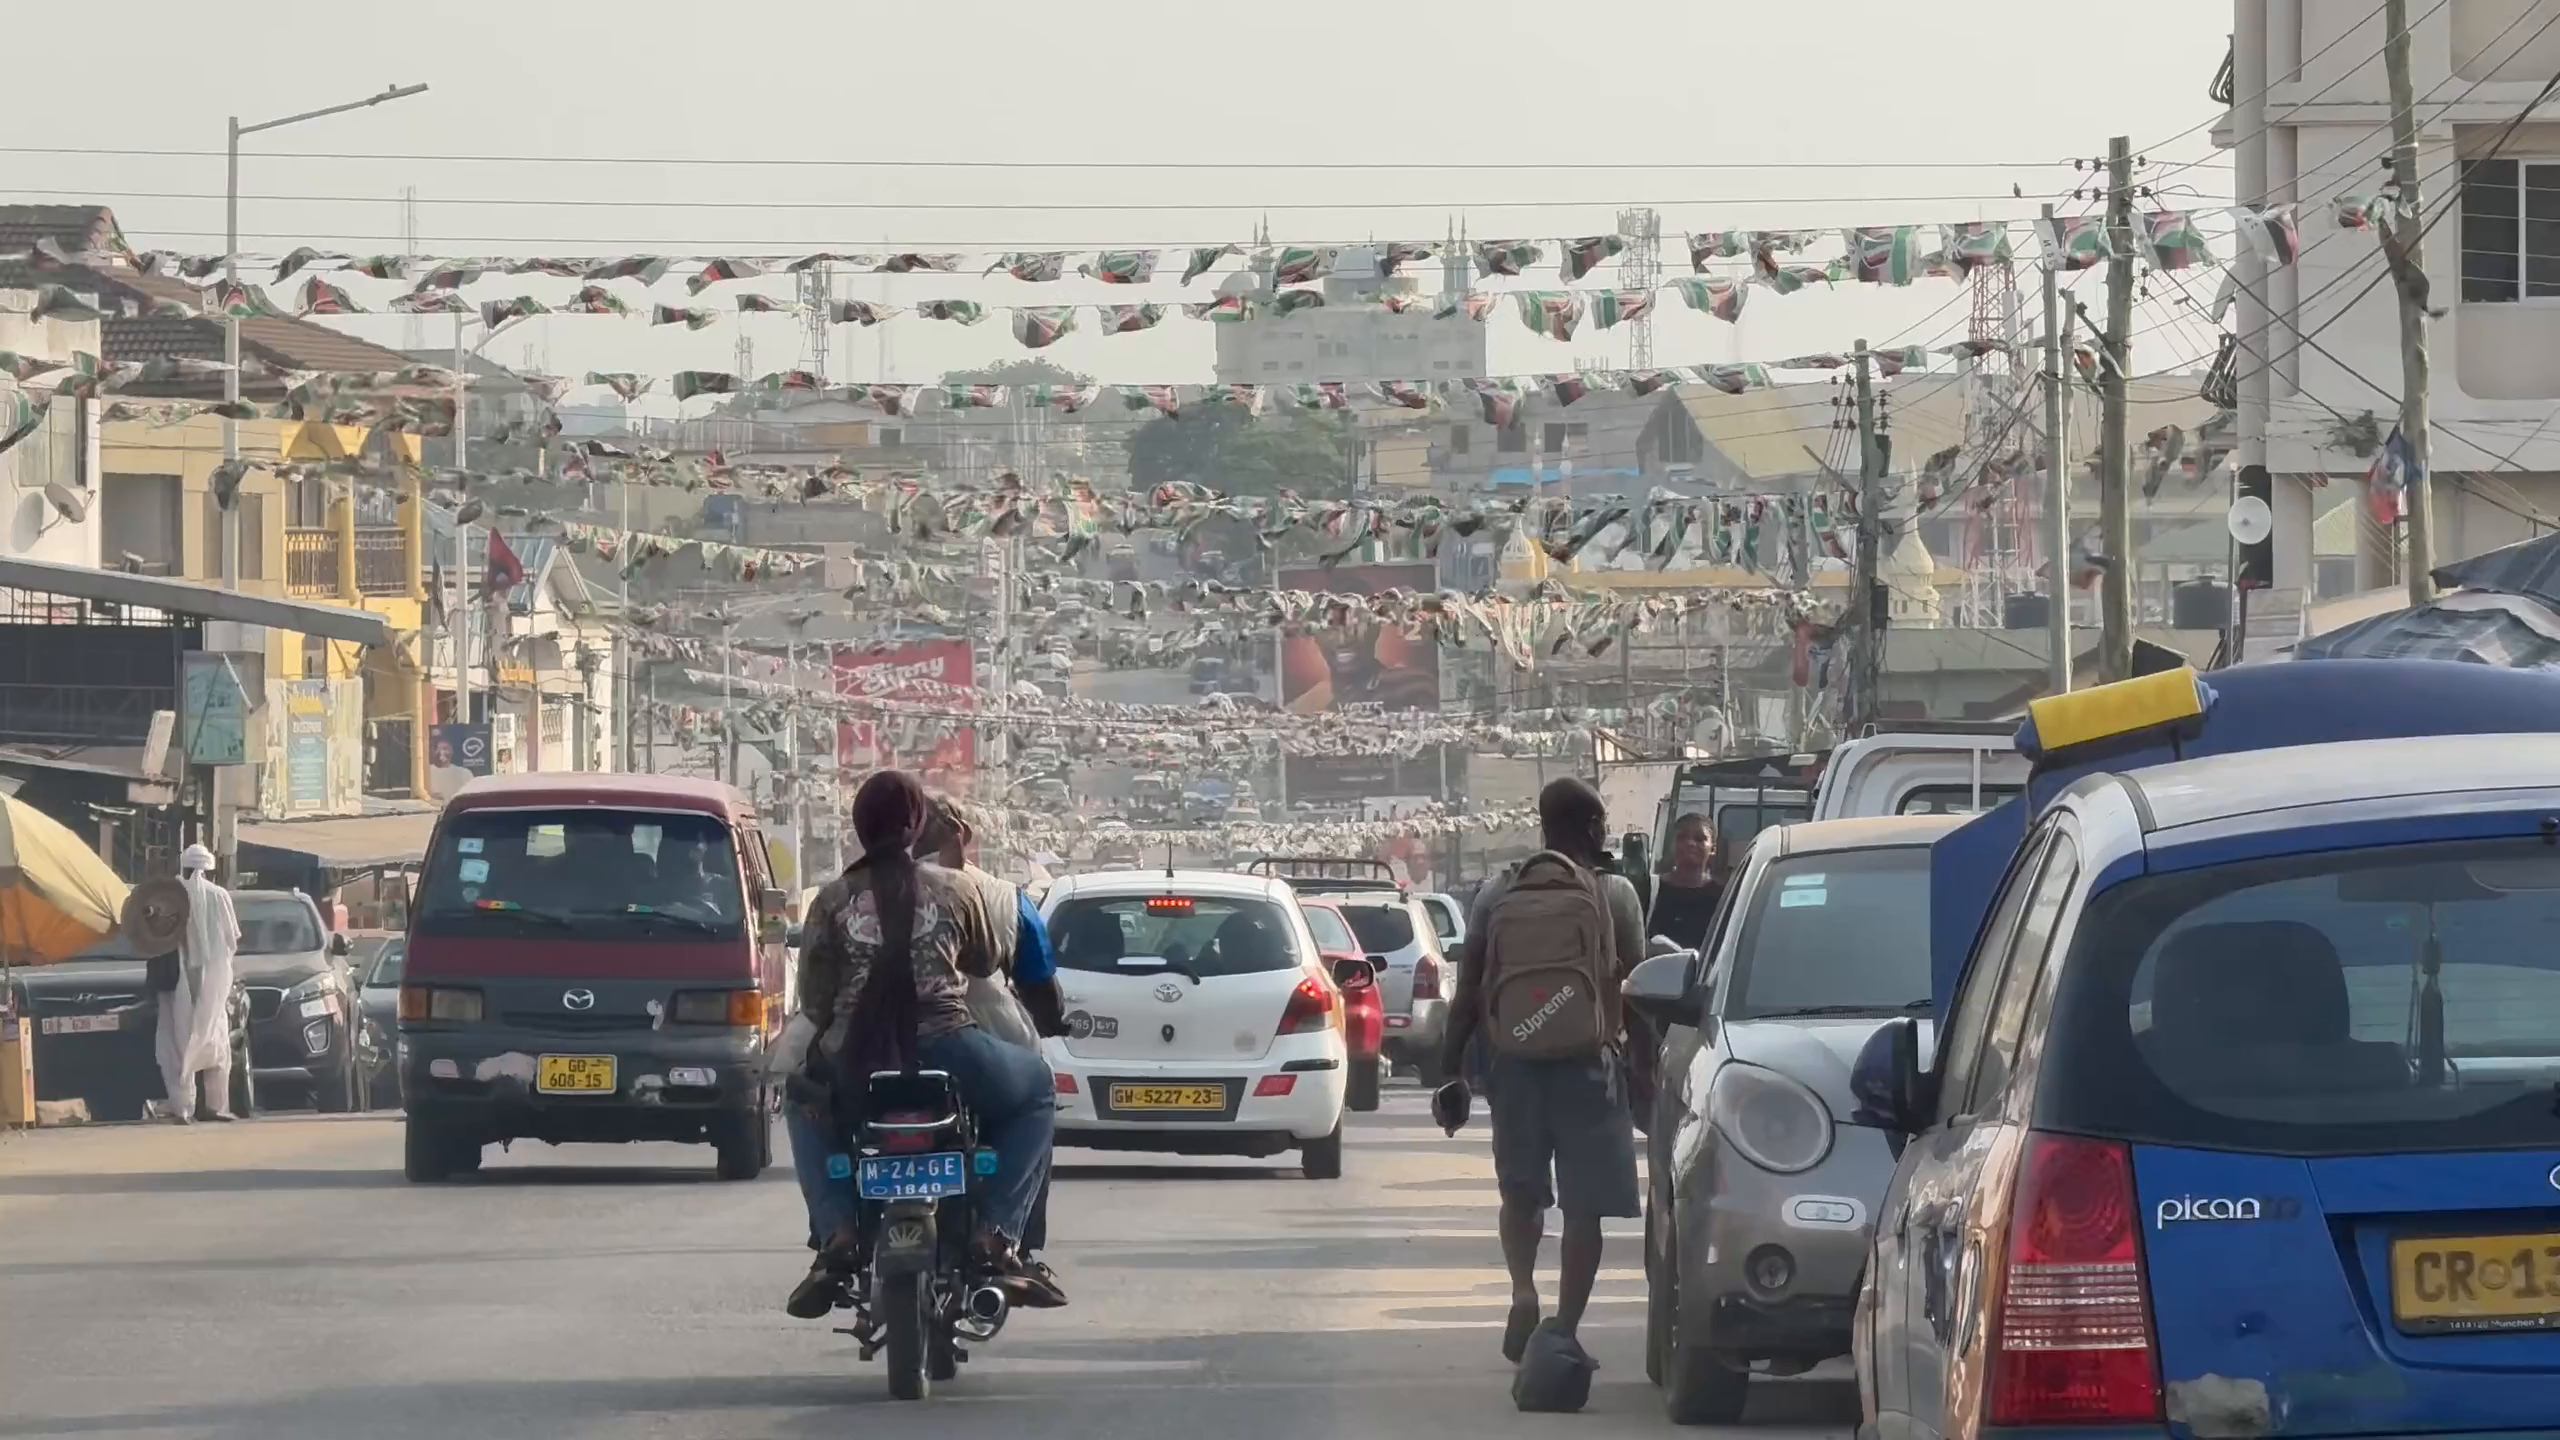

In [ ]:
import cv2
from IPython.display import display
from PIL import Image
video_path = "13219337_2560_1440_24fps.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))
else:
    print("Could not read the video.")

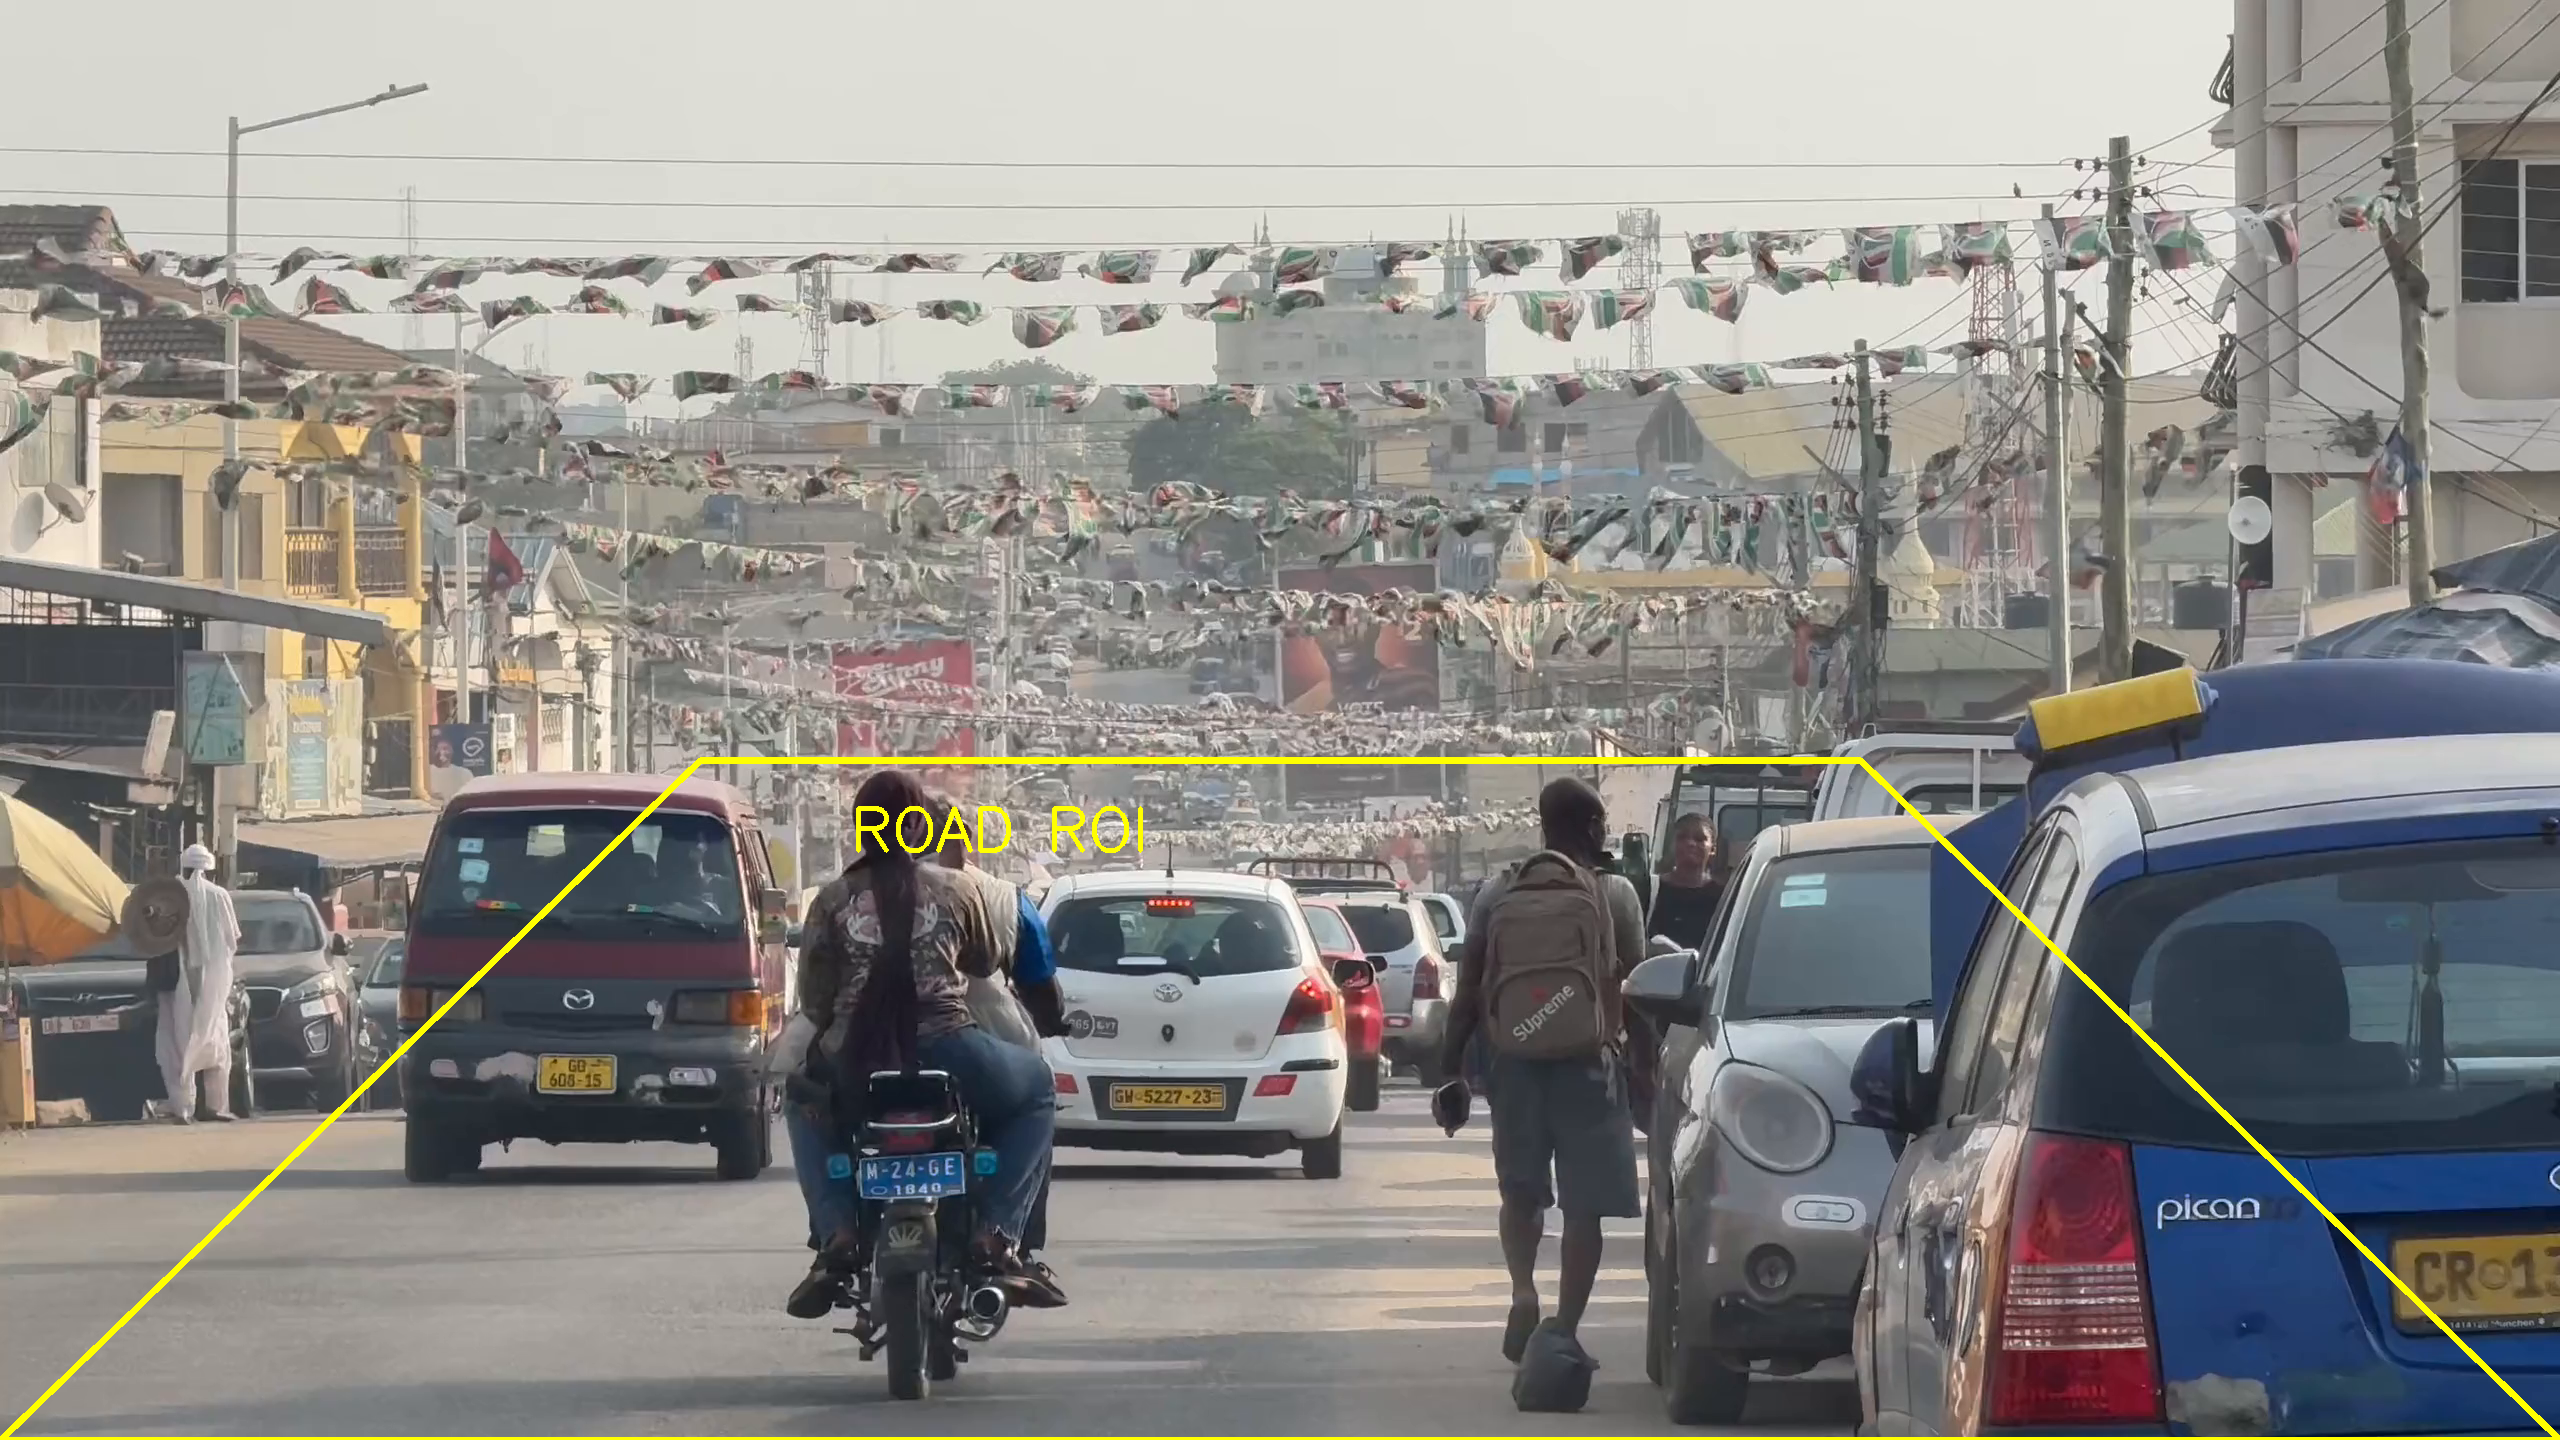

In [ ]:
import cv2
import numpy as np
from IPython.display import display
from PIL import Image
video_path = "13219337_2560_1440_24fps.mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()
if ret:
    road_roi = np.array([
        [700, 760],
        [1860, 760],
        [2560, 1440],
        [0, 1440]
    ], np.int32)
    cv2.polylines(
        frame,
        [road_roi],
        isClosed=True,
        color=(0, 255, 255),
        thickness=5
    )
    cv2.putText(
        frame,
        "ROAD ROI",
        (850, 850),
        cv2.FONT_HERSHEY_SIMPLEX,
        2,
        (0, 255, 255),
        4
    )
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))
else:
    print("Could not read video.")

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
model = YOLO("yolov8n.pt")
video_path = "13219337_2560_1440_24fps.mp4"
road_roi = np.array([
    [700, 760],
    [1860, 760],
    [2560, 1440],
    [0, 1440]
], np.int32)
roi_area = cv2.contourArea(road_roi)
print("Road ROI area:", roi_area)
results = model.track(
    source=video_path,
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    stream=True,
    verbose=False
)
class_names = {
    2: "Car",
    3: "Bike",
    5: "Bus",
    7: "Truck"
}
roi_density_values = []
for result in results:
    vehicle_area = 0
    if result.boxes.xyxy is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        classes = result.boxes.cls.cpu().numpy().astype(int)
        for box, cls in zip(boxes, classes):
            x1, y1, x2, y2 = box
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)
            inside = cv2.pointPolygonTest(
                road_roi,
                (center_x, center_y),
                False
            )
            if inside >= 0:
                box_width = x2 - x1
                box_height = y2 - y1
                area = box_width * box_height
                vehicle_area += area
    density = (vehicle_area / roi_area) * 100
    roi_density_values.append(density)
average_roi_density = np.mean(roi_density_values)
maximum_roi_density = np.max(roi_density_values)
minimum_roi_density = np.min(roi_density_values)
print()
print("================================")
print("ROAD ROI DENSITY ANALYSIS")
print("================================")
print(f"Average ROI Occupancy : {average_roi_density:.2f}%")
print(f"Maximum ROI Occupancy : {maximum_roi_density:.2f}%")
print(f"Minimum ROI Occupancy : {minimum_roi_density:.2f}%")
print("================================")

Road ROI area: 1264800.0

ROAD ROI DENSITY ANALYSIS
Average ROI Occupancy : 40.88%
Maximum ROI Occupancy : 168.90%
Minimum ROI Occupancy : 4.22%


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
model = YOLO("yolov8n.pt")
video_path = "13219337_2560_1440_24fps.mp4"
road_roi = np.array([
    [700, 760],
    [1860, 760],
    [2560, 1440],
    [0, 1440]
], np.int32)
roi_mask = np.zeros((1440, 2560), dtype=np.uint8)
cv2.fillPoly(roi_mask, [road_roi], 255)
roi_area = cv2.countNonZero(roi_mask)
print("Actual Road ROI area:", roi_area)
results = model.track(
    source=video_path,
    tracker="botsort.yaml",
    classes=[2, 3, 5, 7],
    conf=0.4,
    stream=True,
    verbose=False
)
density_values = []
for result in results:
    vehicle_mask = np.zeros((1440, 2560), dtype=np.uint8)
    if result.boxes.xyxy is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        for box in boxes:
            x1, y1, x2, y2 = map(int, box)
            x1 = max(0, min(x1, 2559))
            x2 = max(0, min(x2, 2559))
            y1 = max(0, min(y1, 1439))
            y2 = max(0, min(y2, 1439))
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2
            if cv2.pointPolygonTest(
                road_roi,
                (center_x, center_y),
                False
            ) >= 0:
                cv2.rectangle(
                    vehicle_mask,
                    (x1, y1),
                    (x2, y2),
                    255,
                    -1
                )
    vehicle_mask = cv2.bitwise_and(
        vehicle_mask,
        roi_mask
    )
    occupied_area = cv2.countNonZero(vehicle_mask)
    occupancy = (occupied_area / roi_area) * 100
    density_values.append(occupancy)
average_roi_density = np.mean(density_values)
maximum_roi_density = np.max(density_values)
minimum_roi_density = np.min(density_values)
print()
print("================================")
print("CORRECTED ROAD ROI DENSITY")
print("================================")
print(f"Average ROI Occupancy : {average_roi_density:.2f}%")
print(f"Maximum ROI Occupancy : {maximum_roi_density:.2f}%")
print(f"Minimum ROI Occupancy : {minimum_roi_density:.2f}%")
print("================================")

Actual Road ROI area: 1264820

CORRECTED ROAD ROI DENSITY
Average ROI Occupancy : 32.28%
Maximum ROI Occupancy : 63.49%
Minimum ROI Occupancy : 4.24%


In [ ]:
average_occupancy = np.mean(density_values)
if average_occupancy < 20:
    congestion_status = "LOW"
elif average_occupancy <= 40:
    congestion_status = "MEDIUM"
else:
    congestion_status = "HIGH"
print("================================")
print("FINAL TRAFFIC ANALYSIS")
print("================================")
print(f"Average Vehicles/Frame : {average_vehicles:.2f}")
print(f"Total Vehicles Observed : 65")
print(f"Average Road Occupancy : {average_occupancy:.2f}%")
print(f"Maximum Road Occupancy : {max_occupancy:.2f}%")
print("--------------------------------")
print(f"CONGESTION STATUS : {congestion_status}")
print("================================")

FINAL TRAFFIC ANALYSIS
Average Vehicles/Frame : 6.42
Total Vehicles Observed : 65
Average Road Occupancy : 32.28%
Maximum Road Occupancy : 57.95%
--------------------------------
CONGESTION STATUS : MEDIUM


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
def analyze_traffic(video_path, output_path="/content/traffic_analysis.mp4"):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25
    road_roi = np.array([
        [700, 760],
        [1860, 760],
        [2560, 1440],
        [0, 1440]
    ], np.float32)
    scale_x = width / 2560
    scale_y = height / 1440
    road_roi[:, 0] *= scale_x
    road_roi[:, 1] *= scale_y
    road_roi = road_roi.astype(np.int32)
    roi_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(
        roi_mask,
        [road_roi],
        255
    )
    roi_area = cv2.countNonZero(roi_mask)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (width, height)
    )
    class_names = {
        2: "Car",
        3: "Bike",
        5: "Bus",
        7: "Truck"
    }
    vehicle_counts = {
        "Car": 0,
        "Bike": 0,
        "Bus": 0,
        "Truck": 0
    }
    vehicle_tracks = {}
    vehicles_per_frame = []
    occupancy_values = []
    results = model.track(
        source=video_path,
        tracker="botsort.yaml",
        classes=[2, 3, 5, 7],
        conf=0.4,
        stream=True,
        verbose=False
    )
    for result in results:
        ret, frame = cap.read()
        if not ret:
            break
        current_frame_vehicle_count = 0
        vehicle_mask = np.zeros(
            (height, width),
            dtype=np.uint8
        )
        if result.boxes.id is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)
            ids = result.boxes.id.cpu().numpy().astype(int)
            current_frame_vehicle_count = len(ids)
            for box, cls, track_id in zip(
                boxes,
                classes,
                ids
            ):
                x1, y1, x2, y2 = map(
                    int,
                    box
                )
                x1 = max(0, min(x1, width - 1))
                x2 = max(0, min(x2, width - 1))
                y1 = max(0, min(y1, height - 1))
                y2 = max(0, min(y2, height - 1))
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2
                vehicle_name = class_names.get(
                    cls,
                    "Vehicle"
                )
                if track_id not in vehicle_tracks:
                    vehicle_tracks[track_id] = {
                        "class": cls,
                        "frames": 0
                    }
                vehicle_tracks[track_id]["frames"] += 1
                inside_roi = cv2.pointPolygonTest(
                    road_roi,
                    (center_x, center_y),
                    False
                )
                if inside_roi >= 0:
                    cv2.rectangle(
                        vehicle_mask,
                        (x1, y1),
                        (x2, y2),
                        255,
                        -1
                    )
                cv2.rectangle(
                    frame,
                    (x1, y1),
                    (x2, y2),
                    (0, 255, 0),
                    2
                )
                label = f"{vehicle_name} ID:{track_id}"
                cv2.putText(
                    frame,
                    label,
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )
                cv2.circle(
                    frame,
                    (center_x, center_y),
                    4,
                    (0, 0, 255),
                    -1
                )
        vehicles_per_frame.append(
            current_frame_vehicle_count
        )
        vehicle_mask = cv2.bitwise_and(
            vehicle_mask,
            roi_mask
        )
        occupied_area = cv2.countNonZero(
            vehicle_mask
        )
        occupancy = (
            occupied_area / roi_area
        ) * 100
        occupancy_values.append(
            occupancy
        )
        cv2.polylines(
            frame,
            [road_roi],
            True,
            (0, 255, 255),
            3
        )
        cv2.putText(
            frame,
            "ROAD ROI",
            (
                int(width * 0.40),
                int(height * 0.60)
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 255),
            2
        )
        out.write(frame)
    cap.release()
    out.release()
    valid_tracks = {
        track_id: data
        for track_id, data in vehicle_tracks.items()
        if data["frames"] >= 5
    }
    for track_id, data in valid_tracks.items():
        vehicle_name = class_names.get(
            data["class"]
        )
        if vehicle_name in vehicle_counts:
            vehicle_counts[vehicle_name] += 1
    average_vehicles = np.mean(
        vehicles_per_frame
    )
    maximum_vehicles = np.max(
        vehicles_per_frame
    )
    average_occupancy = np.mean(
        occupancy_values
    )
    maximum_occupancy = np.max(
        occupancy_values
    )
    minimum_occupancy = np.min(
        occupancy_values
    )
    total_vehicles = sum(
        vehicle_counts.values()
    )
    if average_occupancy < 20:
        congestion_status = "LOW"
    elif average_occupancy <= 40:
        congestion_status = "MEDIUM"
    else:
        congestion_status = "HIGH"
    return {
        "cars": vehicle_counts["Car"],
        "bikes": vehicle_counts["Bike"],
        "buses": vehicle_counts["Bus"],
        "trucks": vehicle_counts["Truck"],
        "total_vehicles": total_vehicles,
        "average_vehicles_per_frame": average_vehicles,
        "maximum_vehicles_per_frame": maximum_vehicles,
        "average_occupancy": average_occupancy,
        "maximum_occupancy": maximum_occupancy,
        "minimum_occupancy": minimum_occupancy,
        "congestion": congestion_status,
        "output_video": output_path
    }

In [ ]:
video_path = "13219337_2560_1440_24fps.mp4"
results = analyze_traffic(
    video_path
)
print("================================")
print("TRAFFIC ANALYSIS RESULTS")
print("================================")

print("Cars   :", results["cars"])
print("Bikes  :", results["bikes"])
print("Buses  :", results["buses"])
print("Trucks :", results["trucks"])
print("--------------------------------")
print(
    "Total Vehicles :",
    results["total_vehicles"]
)
print(
    "Average Vehicles/Frame :",
    round(
        results["average_vehicles_per_frame"],
        2
    )
)
print(
    "Average Road Occupancy :",
    round(
        results["average_occupancy"],
        2
    ),
    "%"
)
print(
    "Maximum Road Occupancy :",
    round(
        results["maximum_occupancy"],
        2
    ),
    "%"
)
print("--------------------------------")
print(
    "CONGESTION STATUS :",
    results["congestion"]
)
print("================================")
print(
    "Output video:",
    results["output_video"]
)

TRAFFIC ANALYSIS RESULTS
Cars   : 55
Bikes  : 7
Buses  : 2
Trucks : 1
--------------------------------
Total Vehicles : 65
Average Vehicles/Frame : 6.42
Average Road Occupancy : 32.28 %
Maximum Road Occupancy : 63.49 %
--------------------------------
CONGESTION STATUS : MEDIUM
Output video: /content/traffic_analysis.mp4


In [ ]:
!pip install -q streamlit ultralytics opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 6.2 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import os
import uuid
import shutil
from ultralytics import YOLO
st.set_page_config(
    page_title="Traffic Analysis System",
    page_icon="🚦",
    layout="wide"
)
MODEL_PATH = "yolov8n.pt"
MAX_UPLOAD_SIZE_MB = 500
MAX_PROCESSING_WIDTH = 1280
CONFIDENCE = 0.4
CLASSES = [2, 3, 5, 7]
@st.cache_resource
def load_model():
    return YOLO(MODEL_PATH)
model = load_model()
def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        return None
    width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )
    height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )
    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )
    duration = 0
    if fps > 0:
        duration = frames / fps
    cap.release()
    if width <= 0 or height <= 0:
        return None
    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frames": frames,
        "duration": duration
    }
def analyze_traffic(
    video_path,
    output_path
):
    info = get_video_info(
        video_path
    )
    if info is None:
        raise ValueError(
            "The uploaded video could not be read. "
            "Please try another video format."
        )
    original_width = info["width"]
    original_height = info["height"]
    fps = info["fps"]
    total_frames = info["frames"]
    if fps <= 0:
        fps = 25
    if original_width > MAX_PROCESSING_WIDTH:
        scale = (
            MAX_PROCESSING_WIDTH /
            original_width
        )
        processing_width = (
            int(original_width * scale)
        )
        processing_height = (
            int(original_height * scale)
        )
    else:
        processing_width = original_width
        processing_height = original_height
    cap = cv2.VideoCapture(
        video_path
    )
    if not cap.isOpened():
        raise ValueError(
            "Unable to open video for processing."
        )
    fourcc = cv2.VideoWriter_fourcc(
        *"mp4v"
    )
    out = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (
            processing_width,
            processing_height
        )
    )
    if not out.isOpened():
        cap.release()
        raise ValueError(
            "Unable to create output video."
        )
    car_ids = set()
    bike_ids = set()
    bus_ids = set()
    truck_ids = set()
    total_vehicle_detections = 0
    occupancy_values = []
    processed_frames = 0
    progress = st.progress(0)
    status = st.empty()
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if (
                frame.shape[1]
                != processing_width
                or
                frame.shape[0]
                != processing_height
            ):
                frame = cv2.resize(
                    frame,
                    (
                        processing_width,
                        processing_height
                    ),
                    interpolation=cv2.INTER_AREA
                )
            results = model.track(
                frame,
                persist=True,
                tracker="botsort.yaml",
                classes=CLASSES,
                conf=CONFIDENCE,
                verbose=False
            )
            result = results[0]
            annotated_frame = (
                result.plot()
            )
            frame_vehicle_count = 0
            if (
                result.boxes is not None
                and result.boxes.id is not None
            ):
                track_ids = (
                    result
                    .boxes
                    .id
                    .int()
                    .cpu()
                    .tolist()
                )
                class_ids = (
                    result
                    .boxes
                    .cls
                    .int()
                    .cpu()
                    .tolist()
                )
                for (
                    track_id,
                    class_id
                ) in zip(
                    track_ids,
                    class_ids
                ):
                    frame_vehicle_count += 1
                    if class_id == 2:
                        car_ids.add(
                            track_id
                        )
                    elif class_id == 3:
                        bike_ids.add(
                            track_id
                        )
                    elif class_id == 5:
                        bus_ids.add(
                            track_id
                        )
                    elif class_id == 7:
                        truck_ids.add(
                            track_id
                        )
            total_vehicle_detections += (
                frame_vehicle_count
            )
            frame_area = (
                processing_width *
                processing_height
            )
            vehicle_area = 0
            if result.boxes is not None:
                for box in result.boxes.xyxy:
                    x1, y1, x2, y2 = map(
                        int,
                        box
                    )
                    vehicle_area += max(
                        0,
                        (x2 - x1) *
                        (y2 - y1)
                    )
            if frame_area > 0:
                occupancy = (
                    vehicle_area /
                    frame_area
                ) * 100
                occupancy_values.append(
                    occupancy
                )
            out.write(
                annotated_frame
            )
            processed_frames += 1
            if total_frames > 0:
                percent = (
                    processed_frames /
                    total_frames
                )
                percent = min(
                    percent,
                    1.0
                )
                progress.progress(
                    percent
                )
                status.text(
                    f"Processing frame "
                    f"{processed_frames:,} / "
                    f"{total_frames:,}"
                )
    finally:
        cap.release()
        out.release()
    progress.empty()
    status.empty()
    cars = len(car_ids)
    bikes = len(bike_ids)
    buses = len(bus_ids)
    trucks = len(truck_ids)
    total_vehicles = (
        cars +
        bikes +
        buses +
        trucks
    )
    if processed_frames > 0:
        average_vehicles_per_frame = (
            total_vehicle_detections /
            processed_frames
        )
    else:
        average_vehicles_per_frame = 0
    if occupancy_values:
        average_occupancy = (
            sum(occupancy_values) /
            len(occupancy_values)
        )
        maximum_occupancy = max(
            occupancy_values
        )
    else:
        average_occupancy = 0
        maximum_occupancy = 0
    if maximum_occupancy >= 50:
        congestion = "High"
    elif maximum_occupancy >= 25:
        congestion = "Moderate"
    else:
        congestion = "Low"
    return {
        "cars": cars,
        "bikes": bikes,
        "buses": buses,
        "trucks": trucks,
        "total_vehicles":
            total_vehicles,
        "average_vehicles_per_frame":
            average_vehicles_per_frame,
        "average_occupancy":
            average_occupancy,
        "maximum_occupancy":
            maximum_occupancy,
        "congestion":
            congestion,
        "output_video":
            output_path,
        "original_width":
            original_width,
        "original_height":
            original_height,
        "fps":
            fps,
        "duration":
            info["duration"],
        "processed_frames":
            processed_frames
    }
st.title(
    "🚦 Traffic Analysis System"
)
st.write(
    "AI-Based Vehicle Detection and "
    "Traffic Congestion Analysis"
)
uploaded_file = st.file_uploader(
    "Upload a traffic video",
    type=[
        "mp4",
        "avi",
        "mov",
        "mkv",
        "mpeg",
        "mpg"
    ]
)
if uploaded_file is None:
    st.info(
        "👈 Upload a traffic video to begin."
    )
    st.stop()
file_size_mb = (
    uploaded_file.size /
    (1024 * 1024)
)
if file_size_mb > MAX_UPLOAD_SIZE_MB:
    st.error(
        f"❌ Video is too large "
        f"({file_size_mb:.1f} MB). "
        f"Maximum allowed size is "
        f"{MAX_UPLOAD_SIZE_MB} MB."
    )
    st.stop()
session_id = uuid.uuid4().hex
extension = os.path.splitext(
    uploaded_file.name
)[1].lower()
input_path = (
    f"input_{session_id}{extension}"
)
output_path = (
    f"traffic_output_{session_id}.mp4"
)
try:
    with open(
        input_path,
        "wb"
    ) as f:
        f.write(
            uploaded_file.getbuffer()
        )
except Exception as e:
    st.error(
        "❌ Could not save uploaded video."
    )
    st.exception(e)
    st.stop()
video_info = get_video_info(
    input_path
)
if video_info is None:
    st.error(
        "❌ This video could not be read. "
        "It may be corrupted or use an unsupported codec."
    )
    if os.path.exists(input_path):
        os.remove(input_path)
    st.stop()
st.success(
    f"✅ Uploaded: {uploaded_file.name}"
)
info_col1, info_col2, info_col3, info_col4 = (
    st.columns(4)
)
with info_col1:
    st.metric(
        "Resolution",
        f'{video_info["width"]} × '
        f'{video_info["height"]}'
    )
with info_col2:
    st.metric(
        "FPS",
        f'{video_info["fps"]:.2f}'
    )
with info_col3:
    st.metric(
        "Frames",
        f'{video_info["frames"]:,}'
    )
with info_col4:
    st.metric(
        "Duration",
        f'{video_info["duration"]:.1f} sec'
    )
st.subheader(
    "🎥 Input Video"
)
st.video(
    input_path
)
if st.button(
    "🚦 Analyze Traffic",
    type="primary"
):
    try:
        with st.spinner(
            "Analyzing traffic video..."
        ):
            results = analyze_traffic(
                input_path,
                output_path
            )
        st.success(
            "✅ Traffic analysis completed!"
        )
        st.subheader(
            "🚗 Vehicle Detection"
        )
        col1, col2, col3, col4 = (
            st.columns(4)
        )
        with col1:
            st.metric(
                "🚗 Cars",
                results["cars"]
            )
        with col2:
            st.metric(
                "🏍️ Bikes",
                results["bikes"]
            )
        with col3:
            st.metric(
                "🚌 Buses",
                results["buses"]
            )
        with col4:
            st.metric(
                "🚛 Trucks",
                results["trucks"]
            )
        st.subheader(
            "📊 Traffic Statistics"
        )
        col1, col2, col3 = (
            st.columns(3)
        )
        with col1:
            st.metric(
                "Total Unique Vehicles",
                results["total_vehicles"]
            )
        with col2:
            st.metric(
                "Average Vehicles / Frame",
                round(
                    results[
                        "average_vehicles_per_frame"
                    ],
                    2
                )
            )
        with col3:
            st.metric(
                "Average Road Occupancy",
                f'{results["average_occupancy"]:.2f}%'
            )
        st.subheader(
            "🚦 Congestion Analysis"
        )
        col1, col2 = (
            st.columns(2)
        )
        with col1:
            st.metric(
                "Maximum Road Occupancy",
                f'{results["maximum_occupancy"]:.2f}%'
            )
        with col2:
            congestion = results[
                "congestion"
            ]
            if congestion == "High":
                st.error(
                    "🔴 High Congestion"
                )
            elif congestion == "Moderate":
                st.warning(
                    "🟡 Moderate Congestion"
                )
            else:
                st.success(
                    "🟢 Low Congestion"
                )
        st.subheader(
            "📹 Processing Information"
        )
        st.write(
            f'Original resolution: '
            f'{results["original_width"]} × '
            f'{results["original_height"]}'
        )
        st.write(
            f'FPS: {results["fps"]:.2f}'
        )
        st.write(
            f'Frames processed: '
            f'{results["processed_frames"]:,}'
        )
        st.subheader(
            "🎬 Processed Traffic Video"
        )
        if os.path.exists(
            results["output_video"]
        ):
            st.video(
                results["output_video"]
            )
            with open(
                results["output_video"],
                "rb"
            ) as video_file:
                st.download_button(
                    label=
                        "⬇️ Download Processed Video",
                    data=
                        video_file.read(),
                    file_name=
                        "traffic_analysis.mp4",
                    mime=
                        "video/mp4"
                )
        else:
            st.warning(
                "Processed video was not created."
            )
    except Exception as e:
        st.error(
            "❌ Traffic analysis failed."
        )
        st.exception(e)
st.caption(
    "The system automatically adapts processing "
    "resolution for high-resolution videos to reduce "
    "memory usage."
)

Overwriting app.py


In [ ]:
import os
os.makedirs(".streamlit", exist_ok=True)

In [ ]:
%%writefile .streamlit/config.toml
[server]
maxUploadSize = 500
maxMessageSize = 500

Overwriting .streamlit/config.toml


In [ ]:
!pkill -f streamlit

In [ ]:
!nohup streamlit run app.py --server.address 0.0.0.0 --server.port 8501 > streamlit.log 2>&1 &

In [ ]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Fri, 21 Aug 2026 09:20:43 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 11141
last-modified: Fri, 21 Aug 2026 08:58:43 GMT
etag: "8253c7d56aa0dbdd3d1f86110b81ff8a"
cache-control: no-cache



In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-08-21T09:21:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-21T09:21:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-21T09:21:07Z INF +--------------------------------------------------------------------------------------------+
2026-08-21T09:21:07Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-21T09:21:07Z INF |  https://complimentary-seller-introduction-squad.trycl